# 6주차: 과적합 직관과 미분 심화
**인공지능수학 | Week 06 Lecture**

> **이번 주 목표**
> - 5주차 복선: 관련 없는 특성을 추가하면 왜 훈련 오차가 줄어드는지 직관을 얻는다
> - 과적합이 무엇인지 시각적으로 이해하고, 가중치 크기와의 관계를 본다
> - 지수함수·로그함수 미분 규칙을 익히고 chain rule과 결합한다
> - 7~8주차(MLE, 로지스틱회귀)에서 쓸 핵심 미분 형태를 손에 익힌다

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

---
## 🎯 Aha Moment: 5주차 복선 회수

5주차 마지막에서 이런 현상을 봤습니다.

> 실제 정답과 관련 없는 특성을 추가해도 훈련 MSE가 계속 줄어든다.

아래 두 모델을 비교합니다.  
**모델 A:** 훈련 데이터에 완벽하게 맞춤 (MSE ≈ 0)  
**모델 B:** 훈련 데이터에 적당히 맞춤 (MSE > 0)

어느 쪽이 더 좋은 모델일까요?

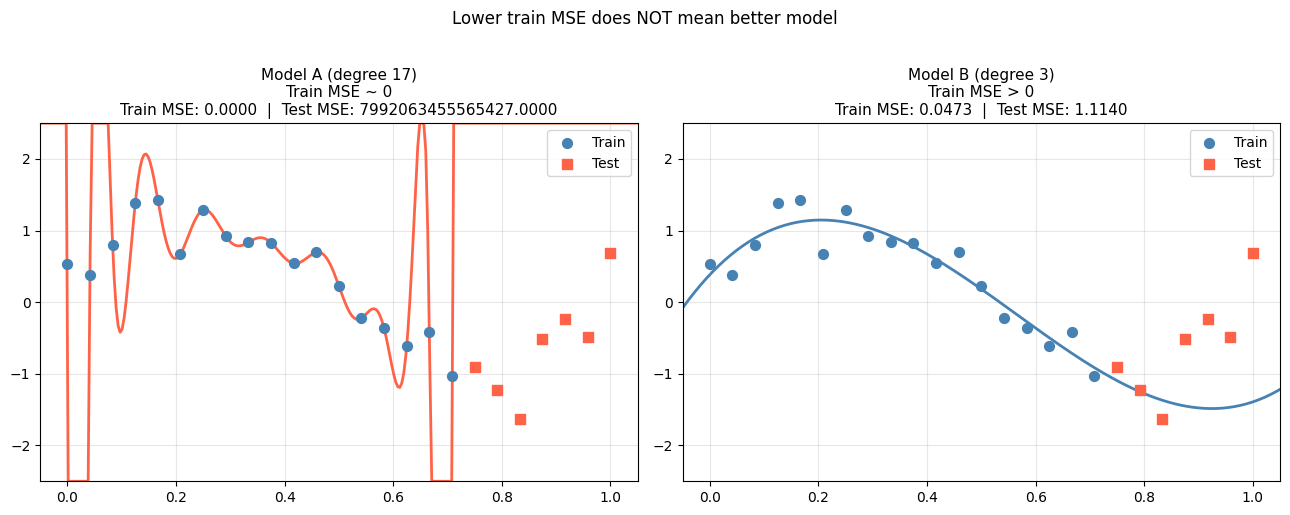

In [3]:
# ---- Aha Moment: overfit vs good fit ----
np.random.seed(0)
x_all = np.linspace(0, 1, 25)
y_all = np.sin(2*np.pi*x_all) + np.random.randn(25)*0.3

x_tr, y_tr = x_all[:18], y_all[:18]   # train
x_te, y_te = x_all[18:], y_all[18:]   # test (unseen)
x_plot = np.linspace(-0.05, 1.05, 300)

coef_A = np.polyfit(x_tr, y_tr, 17)   # overfit
coef_B = np.polyfit(x_tr, y_tr,  3)   # good fit

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, coef, title, col in zip(
        axes,
        [coef_A, coef_B],
        ['Model A (degree 17)\nTrain MSE ~ 0',
         'Model B (degree 3)\nTrain MSE > 0'],
        ['tomato', 'steelblue']):
    curve = np.clip(np.polyval(coef, x_plot), -2.5, 2.5)
    tr_mse = np.mean((np.polyval(coef, x_tr) - y_tr)**2)
    te_mse = np.mean((np.polyval(coef, x_te) - y_te)**2)
    ax.scatter(x_tr, y_tr, color='steelblue', s=50, zorder=4, label='Train')
    ax.scatter(x_te, y_te, color='tomato', s=50, marker='s', zorder=4, label='Test')
    ax.plot(x_plot, curve, color=col, lw=2)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-2.5, 2.5)
    ax.set_title(f'{title}\nTrain MSE: {tr_mse:.4f}  |  Test MSE: {te_mse:.4f}', fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Lower train MSE does NOT mean better model', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

> 모델 A의 훈련 MSE는 거의 0이지만 **테스트 MSE는 훨씬 큽니다.**  
> 모델 B는 훈련 데이터를 완벽히 맞추지 못하지만 **새 데이터에서 더 잘 작동합니다.**

> 👉 *왜 이런 일이 생기는지, 어떻게 완화하는지 살펴보고,  
> 이후 수업(MLE, 로지스틱회귀)을 위한 핵심 미분을 익힙니다.*

---
## 1. 과적합(Overfitting) 직관

### 1-1. 외운 것 vs 이해한 것

시험 준비를 예로 들면:

- **과적합 모델:** 연습 문제의 답을 그대로 외운 학생 — 연습 점수 100점, 새 문제에서 실패
- **좋은 모델:** 개념을 이해한 학생 — 연습 문제에서 약간의 실수, 새 문제에도 잘 대응

$$\underbrace{\text{훈련 데이터에 완벽히 맞춤}}_{\text{노이즈까지 외움}} \neq \underbrace{\text{패턴을 이해함}}_{\text{새 데이터에도 통함}}$$

### 1-2. 가중치 크기와 과적합

과적합된 모델의 특징: **가중치가 매우 크다.**

In [4]:
# ---- Weight magnitude: overfit vs good fit ----
print('Model A (degree 17) — overfit')
print('  Max |weight|:', np.max(np.abs(coef_A)).round(1))
print()
print('Model B (degree 3) — good fit')
print('  Max |weight|:', np.max(np.abs(coef_B)).round(1))
print()
print('가중치가 클수록 입력의 작은 변화에 출력이 크게 요동 -> 노이즈에 민감')

Model A (degree 17) — overfit
  Max |weight|: 29850363982967.9

Model B (degree 3) — good fit
  Max |weight|: 23.9

가중치가 클수록 입력의 작은 변화에 출력이 크게 요동 -> 노이즈에 민감


### 1-3. Weight Decay: 가볍게 소개

가중치가 커지는 것에 페널티를 주면 과적합을 완화할 수 있습니다:

$$L_{\text{reg}}(\mathbf{w}) = \underbrace{\frac{1}{m}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|^2}_{\text{MSE}} + \underbrace{\lambda\|\mathbf{w}\|^2}_{\text{페널티}}$$

$\lambda$가 클수록 가중치를 더 강하게 0 쪽으로 당깁니다.  
이를 **Weight Decay** 또는 **Ridge 정규화**라 부릅니다.  
수학적 분석은 머신러닝 과목에서 자세히 다룹니다.  
지금은 **'큰 가중치에 페널티 → 모델이 단순해짐 → 과적합 완화'** 라는 아이디어만 기억합니다.

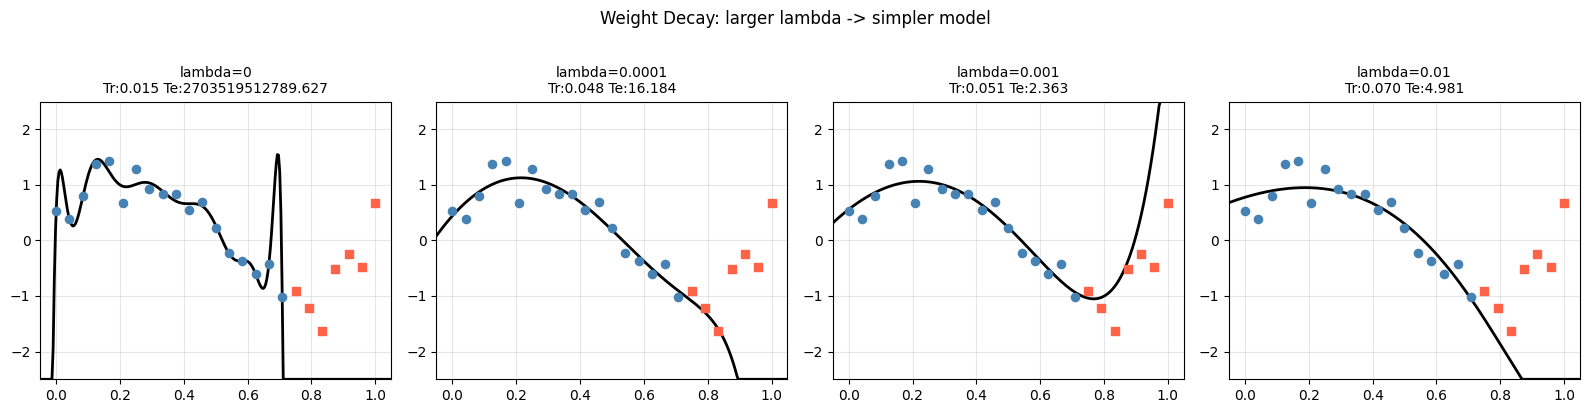

In [5]:
# ---- Weight Decay effect ----
from numpy.linalg import solve

deg = 17
X_poly = np.vander(x_tr, deg+1, increasing=True)

lam_vals = [0, 0.0001, 0.001, 0.01]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, lam in zip(axes, lam_vals):
    A = X_poly.T @ X_poly + lam * np.eye(deg+1)
    w_r = solve(A, X_poly.T @ y_tr)
    X_pl = np.vander(x_plot, deg+1, increasing=True)
    curve = np.clip(X_pl @ w_r, -2.5, 2.5)
    tr_mse = np.mean((X_poly @ w_r - y_tr)**2)
    te_mse = np.mean((np.vander(x_te, deg+1, increasing=True) @ w_r - y_te)**2)
    ax.scatter(x_tr, y_tr, color='steelblue', s=35, zorder=4)
    ax.scatter(x_te, y_te, color='tomato',    s=35, marker='s', zorder=4)
    ax.plot(x_plot, curve, 'k-', lw=2)
    ax.set_xlim(-0.05,1.05); ax.set_ylim(-2.5,2.5)
    ax.set_title(f'lambda={lam}\nTr:{tr_mse:.3f} Te:{te_mse:.3f}', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Weight Decay: larger lambda -> simpler model', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. 지수함수 미분

### 2-1. 기본 규칙

$$\frac{d}{dx}e^x = e^x$$

지수함수는 미분해도 자기 자신입니다. 자연상수 $e$의 가장 중요한 성질입니다.

Chain rule과 결합하면:

$$\frac{d}{dx}e^{f(x)} = e^{f(x)} \cdot f'(x)$$

**예시 3가지:**

$$\frac{d}{dx}e^{3x} = e^{3x} \cdot 3$$

$$\frac{d}{dw}e^{wx} = e^{wx} \cdot x$$

$$\frac{d}{dx}e^{-x} = e^{-x} \cdot (-1) = -e^{-x}$$

In [6]:
# ---- Verify exponential derivative ----
eps = 1e-5

# d/dx e^x at x=2
x_v = 2.0
grad_an  = np.exp(x_v)
grad_num = (np.exp(x_v+eps) - np.exp(x_v-eps)) / (2*eps)
print(f'd/dx e^x  at x=2:        analytical={grad_an:.6f}  numerical={grad_num:.6f}')

# d/dw e^(wx) at w=1.5, x=3
w_v, x_v2 = 1.5, 3.0
grad_an2  = np.exp(w_v*x_v2) * x_v2
grad_num2 = (np.exp((w_v+eps)*x_v2) - np.exp((w_v-eps)*x_v2)) / (2*eps)
print(f'd/dw e^(wx) at w=1.5,x=3: analytical={grad_an2:.4f}  numerical={grad_num2:.4f}')

d/dx e^x  at x=2:        analytical=7.389056  numerical=7.389056
d/dw e^(wx) at w=1.5,x=3: analytical=270.0514  numerical=270.0514


### 2-2. 시그모이드 함수 — 8주차 예고

로지스틱회귀(8주차)의 핵심 함수:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

미분 유도 — $\sigma(x) = (1+e^{-x})^{-1}$으로 쓰고 chain rule 두 번 적용:

**바깥:** $f(u) = u^{-1}$ → $f'(u) = -u^{-2}$  
**안쪽:** $u = 1+e^{-x}$ → $u' = -e^{-x}$

$$\sigma'(x) = \frac{e^{-x}}{(1+e^{-x})^2} = \frac{1}{1+e^{-x}} \cdot \frac{e^{-x}}{1+e^{-x}} = \sigma(x)\cdot(1-\sigma(x))$$

$$\boxed{\sigma'(x) = \sigma(x)\,(1-\sigma(x))}$$

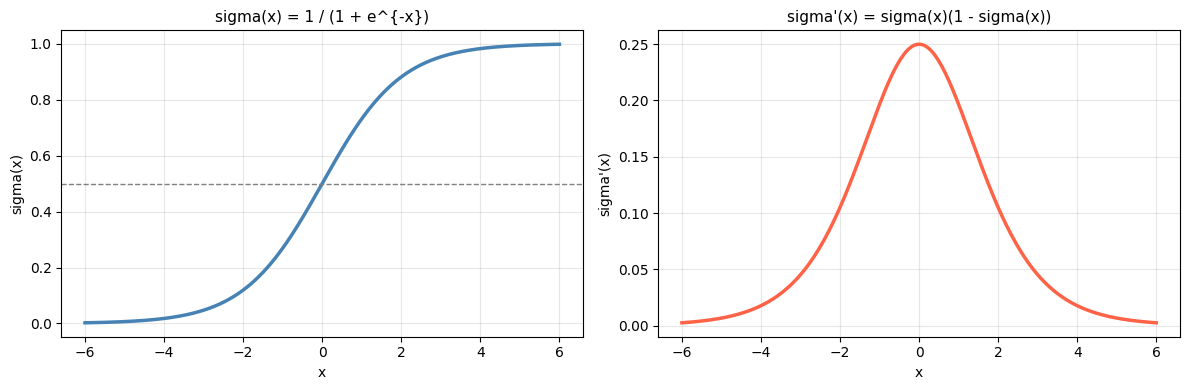

sigma'(1.5): analytical=0.149146  numerical=0.149146  diff=1.65e-12


In [7]:
# ---- Sigmoid and its derivative ----
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

x_range = np.linspace(-6, 6, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_range, sigmoid(x_range), 'steelblue', lw=2.5)
axes[0].axhline(0.5, color='gray', ls='--', lw=1)
axes[0].set_title('sigma(x) = 1 / (1 + e^{-x})', fontsize=11)
axes[0].set_xlabel('x'); axes[0].set_ylabel('sigma(x)'); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_range, sigmoid_grad(x_range), 'tomato', lw=2.5)
axes[1].set_title("sigma'(x) = sigma(x)(1 - sigma(x))", fontsize=11)
axes[1].set_xlabel('x'); axes[1].set_ylabel("sigma'(x)"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Verify
x_t = 1.5
grad_an  = sigmoid_grad(x_t)
grad_num = (sigmoid(x_t+eps) - sigmoid(x_t-eps)) / (2*eps)
print(f"sigma'(1.5): analytical={grad_an:.6f}  numerical={grad_num:.6f}  diff={abs(grad_an-grad_num):.2e}")

---
## 3. 로그함수 미분

### 3-1. 기본 규칙

$$\frac{d}{dx}\ln x = \frac{1}{x} \qquad (x > 0)$$

Chain rule과 결합하면:

$$\frac{d}{dx}\ln f(x) = \frac{f'(x)}{f(x)}$$

**예시 3가지:**

$$\frac{d}{dw}\ln(wx) = \frac{x}{wx} = \frac{1}{w}$$

$$\frac{d}{dx}\ln(x^2+1) = \frac{2x}{x^2+1}$$

$$\frac{d}{dx}\ln(1+e^{x}) = \frac{e^{x}}{1+e^{x}} = \sigma(x)$$

마지막 줄이 핵심입니다 — **로그와 지수가 만나면 시그모이드가 나옵니다.**

### 3-2. MLE와의 연결 — 7주차 예고

7주차 MLE(최대우도추정)에서 최적화할 함수:

$$\ell(\mathbf{w}) = \sum_{i=1}^{m} \ln P(y_i \mid \mathbf{x}_i, \mathbf{w})$$

이 함수를 $\mathbf{w}$로 미분하려면 **로그 미분 + chain rule** 이 핵심입니다.  
지금 연습해두면 7주차 유도가 자연스럽게 따라옵니다.

In [8]:
# ---- Verify log derivative ----
x_v = 3.0
grad_an  = 1/x_v
grad_num = (np.log(x_v+eps) - np.log(x_v-eps)) / (2*eps)
print(f'd/dx ln(x) at x=3:       analytical={grad_an:.6f}  numerical={grad_num:.6f}')

# d/dx ln(1+e^x) = sigma(x)
x_v2 = 2.0
grad_an2  = sigmoid(x_v2)
grad_num2 = (np.log(1+np.exp(x_v2+eps)) - np.log(1+np.exp(x_v2-eps))) / (2*eps)
print(f'd/dx ln(1+e^x) at x=2:   analytical(sigma)={grad_an2:.6f}  numerical={grad_num2:.6f}')

d/dx ln(x) at x=3:       analytical=0.333333  numerical=0.333333
d/dx ln(1+e^x) at x=2:   analytical(sigma)=0.880797  numerical=0.880797


---
## 4. Chain Rule 심화 — 합성함수 연습

### 4-1. 미분 규칙 총정리

|&nbsp;&nbsp;&nbsp;&nbsp; 함수 $f(x)$ &nbsp;&nbsp;&nbsp;| &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;미분 $f'(x)$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 주차 |
|---|---|---|
| $x^n$ | $nx^{n-1}$ | 4주차 |
| $(f(x))^n$ | $n(f(x))^{n-1} \cdot f'(x)$ | 4주차 chain rule |
| $e^x$ | $e^x$ | **6주차** |
| $e^{f(x)}$ | $e^{f(x)} \cdot f'(x)$ | **6주차** |
| $\ln x$ | $\dfrac{1}{x}$ | **6주차** |
| $\ln f(x)$ | $\dfrac{f'(x)}{f(x)}$ | **6주차** |
| $\sigma(x)$ | $\sigma(x)(1-\sigma(x))$ | **6주차** |

### 4-2. 중요 합성함수 예제

로지스틱회귀(8주차)에서 정확히 이 형태가 필요합니다.

**예제 1:** $$\dfrac{d}{dw}\ln\sigma(wx) = \frac{1}{\sigma(wx)} \cdot \sigma(wx)(1-\sigma(wx)) \cdot x = (1-\sigma(wx)) \cdot x$$

**예제 2:** $$\dfrac{d}{dw}\ln(1-\sigma(wx))= \frac{-\sigma(wx)(1-\sigma(wx))}{1-\sigma(wx)} \cdot x = -\sigma(wx) \cdot x$$

> 이 두 식이 합쳐지면 **이진 교차 엔트로피(BCE) gradient**가 됩니다 — 8주차에서 다시 만납니다.

In [ ]:
# ---- Verify chain rule examples ----
w_v, x_v = 0.8, 2.0

# Example 1: d/dw ln(sigma(wx)) = (1 - sigma(wx)) * x
f1 = lambda w: np.log(sigmoid(w*x_v))
grad_an1  = (1 - sigmoid(w_v*x_v)) * x_v
grad_num1 = (f1(w_v+eps) - f1(w_v-eps)) / (2*eps)
print('Example 1: d/dw ln(sigma(wx))')
print(f'  analytical = (1-sigma)*x = {grad_an1:.6f}')
print(f'  numerical              = {grad_num1:.6f}')
print()

# Example 2: d/dw ln(1 - sigma(wx)) = -sigma(wx) * x
f2 = lambda w: np.log(1 - sigmoid(w*x_v))
grad_an2  = -sigmoid(w_v*x_v) * x_v
grad_num2 = (f2(w_v+eps) - f2(w_v-eps)) / (2*eps)
print('Example 2: d/dw ln(1 - sigma(wx))')
print(f'  analytical = -sigma*x = {grad_an2:.6f}')
print(f'  numerical           = {grad_num2:.6f}')

---
## 5. 미분 통합 정리 — 파트 2에서 파트 3으로

| 주차 | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;함수&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;핵심 미분 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;| 역할 |
|---|---|---|---|
| 3주차 | $(wx-y)^2$ | $2(wx-y)\cdot x$ | MSE gradient |
| 4주차 | 합성함수 | chain rule: 바깥×안 | gradient 유도 도구 |
| 5주차 | $\|\mathbf{X}\mathbf{w}-\mathbf{y}\|^2$ | $\frac{2}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$ | 다변수 gradient |
| **6주차** | $e^{f(x)},\ \ln f(x),\ \sigma(x)$ | 위 표 참고 | **7~8주차 기반** |

| 다음 주차 |&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;함수&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 필요한 미분 |
|---|---|---|
| 7주차 | $\ln P(y_i \mid \mathbf{x}_i, \mathbf{w})$ | 로그 미분 |
| 8주차 | $\ln\sigma(\mathbf{w}^T\mathbf{x})$ | 로그 + 시그모이드 chain rule |
| 11주차 | $-\sum p\ln q$ | 로그 미분 |

---
## ✏️ 익히기 활동 (25분)

### 문제 1: 미분 규칙 적용 (10분)

아래 함수들을 미분하고 수치 검증으로 확인하세요.

**(1-a)** $f(x) = e^{3x}$를 $x$에 대해 미분 → $f'(x) = $ ______

**(1-b)** $f(w) = \ln(w^2+1)$을 $w$에 대해 미분 → $f'(w) = $ ______

**(1-c)** $f(w) = \sigma(2w)$를 $w$에 대해 미분 → $f'(w) = $ ______

In [ ]:
# Problem 1: fill in and verify
eps = 1e-5
x_t, w_t = 1.5, 0.8

# (1-a) d/dx e^(3x)
f_a    = lambda x: np.exp(3*x)
ans_a  = ______                                         # fill in
num_a  = (f_a(x_t+eps) - f_a(x_t-eps)) / (2*eps)
print(f'(1-a) analytical={ans_a:.4f}  numerical={num_a:.4f}  match={np.isclose(ans_a, num_a)}')

# (1-b) d/dw ln(w^2 + 1)
f_b    = lambda w: np.log(w**2 + 1)
ans_b  = ______                                         # fill in
num_b  = (f_b(w_t+eps) - f_b(w_t-eps)) / (2*eps)
print(f'(1-b) analytical={ans_b:.4f}  numerical={num_b:.4f}  match={np.isclose(ans_b, num_b)}')

# (1-c) d/dw sigma(2w)
f_c    = lambda w: sigmoid(2*w)
ans_c  = ______                                         # fill in
num_c  = (f_c(w_t+eps) - f_c(w_t-eps)) / (2*eps)
print(f'(1-c) analytical={ans_c:.4f}  numerical={num_c:.4f}  match={np.isclose(ans_c, num_c)}')

### 문제 2: Chain Rule 전개 (5분)

$f(w) = e^{-(wx-y)^2}$를 $w$에 대해 미분하세요.

힌트: 바깥 $e^{(\cdot)}$ → 안쪽 $-(wx-y)^2$ 순서

$$f'(w) = e^{-(wx-y)^2} \cdot \frac{d}{dw}[-(wx-y)^2] = $$

In [ ]:
# Problem 2: verify
x_p, y_p, w_p = 2.0, 1.0, 0.5
f_p2   = lambda w: np.exp(-(w*x_p - y_p)**2)
ans_p2 = ______                                         # fill in
num_p2 = (f_p2(w_p+eps) - f_p2(w_p-eps)) / (2*eps)
print(f'Problem 2: analytical={ans_p2:.6f}  numerical={num_p2:.6f}  match={np.isclose(ans_p2, num_p2)}')

### 🐛 버그 문제 (10분)

아래 코드는 시그모이드 미분을 구현했지만 틀렸습니다.  
수치 미분과 비교해서 버그를 찾고, 수학적으로 왜 틀렸는지 설명하세요.

*교실에서 팀 활동으로 해결합니다.*

In [ ]:
# 🐛 Bug Hunt: wrong sigmoid derivative
def sigmoid_grad_buggy(x):
    s = sigmoid(x)
    return s * (1 + s)     # 🐛

x_vals = np.array([-2.0, 0.0, 1.0, 2.0])
print(f"{'x':>6}  {'buggy':>10}  {'numerical':>10}  {'match':>6}")
for xv in x_vals:
    buggy = sigmoid_grad_buggy(xv)
    num   = (sigmoid(xv+eps) - sigmoid(xv-eps)) / (2*eps)
    print(f'{xv:>6.1f}  {buggy:>10.6f}  {num:>10.6f}  {str(np.isclose(buggy,num)):>6}')

print()
print('버그 원인:   ______')
print('올바른 공식: ______')

---
## 🤖 LLM 파트너 가이드

### 프롬프트 1: 미분 연습
```
f(w) = ln(sigma(w^2 * x)) 를 w에 대해 미분하는 과정을
chain rule을 단계별로 적용해서 보여주세요.
바깥 함수 → 중간 함수 → 안쪽 함수 순서로 설명해주세요.
```

### 프롬프트 2: 검증 (답 직접 요청 금지)
```
내가 계산한 d/dw ln(1-sigma(wx)) = -sigma(wx)*x 가 맞는지
바로 알려주지 말고, chain rule 각 단계를 확인하는 질문을 해주세요.
```

> **원칙:** 미분 결과가 맞는지 확인할 때 LLM에 바로 답을 구하지 말고,  
> 수치 미분으로 먼저 검증한 뒤 틀리면 LLM에 힌트를 요청하세요.

---
## 📌 다음 주 예고: 확률 기초와 MLE (7주차)

이번 주에 연습한 로그 미분이 바로 사용됩니다.

$$\ell(\mathbf{w}) = \sum_{i=1}^{m} \ln P(y_i \mid \mathbf{x}_i, \mathbf{w})$$

이 함수를 최대화하는 $\mathbf{w}$를 구하는 것이 **MLE(최대우도추정)**입니다.

**준비 포인트:**
- $\dfrac{d}{dx}\ln f(x) = \dfrac{f'(x)}{f(x)}$ 를 손에 익혀두세요
- $\sigma'(x) = \sigma(x)(1-\sigma(x))$ 를 기억해두세요